In [98]:
import torch
import matplotlib.pyplot as plt

In [99]:
import math

torch.manual_seed(42)

angle=math.pi*45/180

print(f"angle:{angle}, cos:{math.cos(angle)}, sin:{math.sin(angle)}")

angle:0.7853981633974483, cos:0.7071067811865476, sin:0.7071067811865475


In [100]:
# draw a circle
# 100 points within [-1,1]
n_points=100
theta=torch.linspace(0,2*torch.pi,n_points)
points=torch.stack([torch.cos(theta),torch.sin(theta)], dim=1)

print(f'n_points:{n_points}, theta:{theta.shape}, points:{points.shape}')

n_points:100, theta:torch.Size([100]), points:torch.Size([100, 2])


/tmp/ipykernel_73453/3989953332.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()                   # 显示图例区分两者


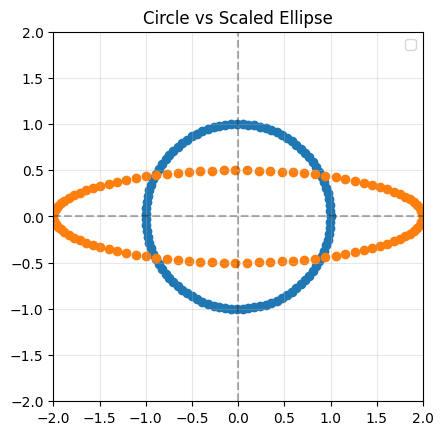

In [109]:
# scale operation, x scaled by 2, y scaled by 0.5
a=2.0
b=0.5
S=torch.tensor([ [a,0.0], [0.0,b]])

# scale operation , yT=(Av)T
scaled_points=points@S  # 或 torch.matmul(points, S)

# plot
plt.xlim(-2,2)
plt.ylim(-2,2)
plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='--', alpha=0.3)
plt.scatter(points[:,0], points[:,1])  # draw circle
plt.scatter(scaled_points[:,0], scaled_points[:,1]) # draw eclipse
plt.gca().set_aspect('equal')  # 关键：保持比例
plt.legend()                   # 显示图例区分两者
plt.grid(True, alpha=0.3)
plt.title('Circle vs Scaled Ellipse')
plt.show()

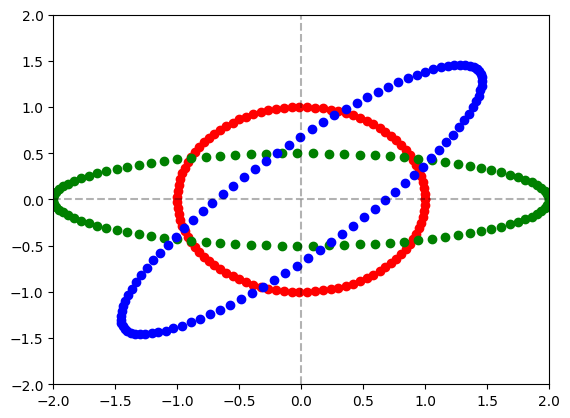

In [102]:
# rotation operation
R:torch.Tensor=torch.tensor([[math.cos(angle), -math.sin(angle)],
                [math.sin(angle), math.cos(angle)]])
R_T=R.t() # another view, memory not touched

# do rotation
rotated_points=scaled_points @ R_T

# plot
plt.xlim(-2,2)
plt.ylim(-2,2)
plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='--', alpha=0.3)
plt.scatter(points[:,0], points[:,1], c='r')  # draw circle
plt.scatter(scaled_points[:,0], scaled_points[:,1], c='g') # draw eclipse
plt.scatter(rotated_points[:,0], rotated_points[:,1], c='b') # draw rotated eclipse
plt.show()


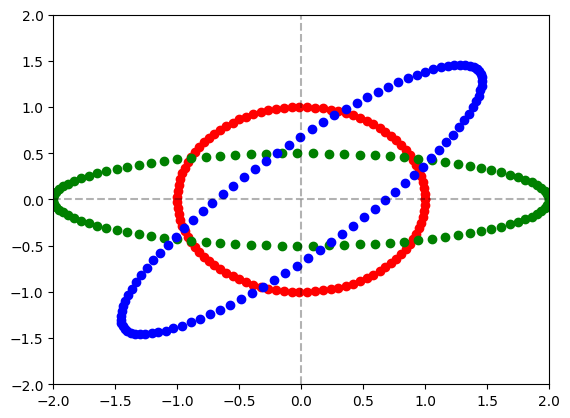

In [103]:
# combine operaton, scale then rotate
combine_mat=(R@S)
combine_mat_T=(R@S).T  # view, memory shared and not touched

# do combine operation
combine_points=points@combine_mat_T

# plot
plt.xlim(-2,2)
plt.ylim(-2,2)
plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='--', alpha=0.3)
plt.scatter(points[:,0], points[:,1], c='r')  # draw circle
plt.scatter(scaled_points[:,0], scaled_points[:,1], c='g') # draw eclipse
plt.scatter(rotated_points[:,0], rotated_points[:,1], c='b') # draw rotated eclipse
plt.show()


In [104]:
# 特征分解
eigen_values, eigen_vecs=torch.linalg.eig(combine_mat)
print(f'combine_mat:{combine_mat}')
print(f'======================')
print(f'eigen_values:{eigen_values}')
print(f'======================')
print(f'eigen_vecs:{eigen_vecs}')

combine_mat:tensor([[ 1.4142, -0.3536],
        [ 1.4142,  0.3536]])
eigen_values:tensor([0.8839+0.4677j, 0.8839-0.4677j])
eigen_vecs:tensor([[0.3354+0.2958j, 0.3354-0.2958j],
        [0.8944+0.0000j, 0.8944-0.0000j]])


In [113]:
# 二次型, 
# x_w=R*S*u, u是单位圆，S是缩放，R是旋转
# 马氏距离， d=xw-mu,  d_T*(R*S_inv*S_inv*R_T)*d, xw是世界坐标系中一个点，mu是椭圆的中心点坐标，向量d是去偏移以后的向量
# 判断任意点xw在椭圆上，椭圆内，椭圆外
R_T=R.T
M=R@torch.diag(torch.tensor([a*a,b*b]))@R_T
M_inv=R@torch.diag(torch.tensor([1/(a*a), 1/(b*b)]))@R_T
print(f'M.shape:{M.shape}, M_inv.shape:{M_inv.shape}')

# test d
u=torch.tensor([1.0,0]) # shape (2,)
x_w=combine_mat@u # shape (2,1)
x_w_1=x_w*1.0 # shape (2,1)
x_w_2=x_w*0.9 # shape (2,1)
x_w_3=x_w*1.1 # shape (2,1)

# calculate distance
dist_x_w_1=x_w_1.T@M_inv@x_w_1
dist_x_w_2=x_w_2.T@M_inv@x_w_2
dist_x_w_3=x_w_3.T@M_inv@x_w_3

print(f"dist_x_w_1:{dist_x_w_1}")
print(f"dist_x_w_2:{dist_x_w_2}")
print(f"dist_x_w_3:{dist_x_w_3}")


M.shape:torch.Size([2, 2]), M_inv.shape:torch.Size([2, 2])
dist_x_w_1:0.9999995827674866
dist_x_w_2:0.8099993467330933
dist_x_w_3:1.2099995613098145
